# GWB iniettato ai valori EPTA DR2new: log10_A = -14.0, gamma = 2.7

Dati simulati in `Simulations.ipynb` (seed `jax.random.key(1)`, salvati in `sim_data_noiseGWB_A140_g27/`) con red noise + DM + scattering + GWB. Li analizzo con il solito modello a 6 parametri **senza** termine GWB, come per le ampiezze -14.5, -15.0, -15.5.

Valori del GWB da EPTA DR2 III (A&A 678, A50, 2023, Sez. 4.1): DR2new, log10_A = -13.94, gamma = 2.71.

## Setup comune

Copia delle celle 0, 1, 3, 4, 6, 7, 9 di `Likelihood.ipynb`.

In [1]:
import numpy as np
import os, glob, json
import pickle

import sys

# this is the path to the discovery folder
sys.path.insert(0, "./")
import discovery_new as ds

import matplotlib.pyplot as plt
import scipy
import jax.numpy as jnp

from scipy.stats import uniform
import re
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
from scipy.stats import uniform
import jax

import time
import emcee

Optional mpi4py package is not installed.  MPI support is not available.


In [2]:
# path to the folder with the data
path = './dati/DR2low_feathers/'
s_dsfiles = np.sort(os.listdir(path))
psr = [ds.pulsar.Pulsar.read_feather(path + f'{psrfile}') for psrfile in s_dsfiles][9] # we are only analysing pulsar #9

In [3]:
# data
model = [psr.residuals]
# timing model
model += [ds.makegp_timing(psr, svd=True)]
# white noise parameters
model += [ds.makenoise_measurement(psr, psr.noisedict, tnequad = True, ecorr=True)]
# red noise paramters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_red_components'], T=ds.getspan(psr), name='red_noise' ))
# DM variation parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_dm_components'], T=ds.getspan(psr), name='dm_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 2.0, tndm = False)))
# scattering noise parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_chrom_components'], T=ds.getspan(psr), name='sv_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 4.0, tndm = False)))

In [4]:
logL = ds.PulsarLikelihood(model).logL

In [5]:
# annoying function needed because the function logL want a dictionary as input, but our sampler wants a likelihood with an array as input
# so we have to switch from one to another :(
def params_dict_from_array(x):
    # ensure x is a plain numpy array before slicing
    x = np.asarray(x)
    return dict(zip(logL.params, x))

In [6]:
##### Cell for the prior distributions ###################################################################################

# dictionary with minimum and maximum value of the prior distribution
my_priordict = {}
my_priordict["(.*_)?sv_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?sv_gp_alpha.*"] = [0, 10]
my_priordict["(.*_)?sv_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_log10_A.*"] = [-10, 1]
my_priordict["(.*_)?sw_gamma.*"] = [-5, 6]
my_priordict["(.*_)?dm_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?dm_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?red_noise_gamma.*"] = [0, 7]
my_priordict["(.*_)?red_noise_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_n_earth.*"] = [0, 30]


def build_priors(param_names, priordict):
    """
    Build a {param_name: scipy dist} dict with uniform prior distributions in the range
    """
    priors = {}
    unmatched = []
    for name in param_names:
        matched = False
        for pattern, (lo, hi) in priordict.items():
            if re.fullmatch(pattern, name):
                priors[name] = uniform(loc=lo, scale=hi - lo) ## this is where the uniform distribution is defined
                matched = True
                break
        if not matched:
            unmatched.append(name)

    if unmatched:
        print(f"Warning: no prior found for {len(unmatched)} parameters, "
              f"falling back to standard normal:\n  {unmatched}")
    return priors

priors = build_priors(logL.params, my_priordict)
priors

def log_prior(x):
    """Compute log prior"""
    params = params_dict_from_array(x)
    
    logp = 0.0
    for name, value in params.items():
        if name in priors:
            logp += priors[name].logpdf(value)
        else:
            # Default: standard normal prior
            if isinstance(value, np.ndarray):
                logp += -0.5 * np.sum(value**2)
            else:
                logp += -0.5 * value**2
    
    return logp

def prior_draw():
    """Draw from prior and return as flat array"""
    x = []
    for name in logL.params:
        x.append(priors[name].rvs())
    return np.array(x)

x0 = prior_draw()
x0

array([  6.09123663, -15.72376672,   2.3697461 , -17.53295696,
         6.25348575, -15.27171223])

In [7]:
@jax.jit # compile the likelihood in jax to make it faster
def _jit_logL(params_array):
    params = dict(zip(logL.params, params_array))
    return logL(params)

_jit_logL(x0)

def log_likelihood(x): 
    """
    Likelihood function that is given to the samples, it uses the jitted (=faster) version of the likelihood
    """
    x = np.asarray(x, dtype=np.float64)
    result = _jit_logL(jnp.array(x))
    return float(np.array(result))  # always a plain Python float

## Catene di confronto (lette da disco, nessun sampling)

- `chain`: dati reali DR2low (cella 13 dell'originale)
- `chain_sim`: simulazione senza GWB con **lo stesso seed** `key(1)` (cella 61 dell'originale)

In [8]:
# read the output chain that has shape (n_samples, n_parameters)
chain = np.loadtxt('./test/chain_1.txt')[:, :-4]
chain = chain[len(chain) // 4:] # remove first 25% from the chain
chain.shape

(75001, 6)

In [9]:
chain_sim = np.loadtxt('./test_sim/chain_1.txt')[:, :-4]
chain_sim = chain_sim[len(chain_sim)//4:]
print('shape chain_sim:', chain_sim.shape)

shape chain_sim: (75001, 6)


## Dati simulati con GWB (log10_A = -14.0, gamma = 2.7)

In [10]:
sim_gwb4_psr = ds.pulsar.Pulsar.read_feather('sim_data_noiseGWB_A140_g27/J1640+2224')
print('nome     :', sim_gwb4_psr.name)
print('N_TOA    :', len(sim_gwb4_psr.toas))
print('shape M  :', sim_gwb4_psr.Mmat.shape)

nome     : J1640+2224
N_TOA    : 6777
shape M  : (6777, 39)


In [11]:
# analizzo i dati con GWB (A=-14.0, gamma=2.7) usando lo stesso modello a 6 par dei dati reali (SENZA GWB)
model_sim_gwb4 = [sim_gwb4_psr.residuals]
model_sim_gwb4 += [ds.makegp_timing(sim_gwb4_psr, svd=True)]
model_sim_gwb4 += [ds.makenoise_measurement(sim_gwb4_psr, sim_gwb4_psr.noisedict, tnequad=True, ecorr=True)]
model_sim_gwb4.append(ds.makegp_fourier(sim_gwb4_psr, ds.powerlaw, sim_gwb4_psr.noisedict[sim_gwb4_psr.name + '_red_components'],
                                        T=ds.getspan(sim_gwb4_psr), name='red_noise'))
model_sim_gwb4.append(ds.makegp_fourier(sim_gwb4_psr, ds.powerlaw, sim_gwb4_psr.noisedict[sim_gwb4_psr.name + '_dm_components'],
                                        T=ds.getspan(sim_gwb4_psr), name='dm_gp',
                                        fourierbasis=ds.make_dmfourierbasis(alpha=2.0, tndm=False)))
model_sim_gwb4.append(ds.makegp_fourier(sim_gwb4_psr, ds.powerlaw, sim_gwb4_psr.noisedict[sim_gwb4_psr.name + '_chrom_components'],
                                        T=ds.getspan(sim_gwb4_psr), name='sv_gp',
                                        fourierbasis=ds.make_dmfourierbasis(alpha=4.0, tndm=False)))

logL_sim_gwb4 = ds.PulsarLikelihood(model_sim_gwb4).logL
logL_sim_gwb4.params   # attesi 6 parametri, nello stesso ordine di logL.params

['J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [12]:
# controllo: stessi parametri e stesso ordine dell'analisi reale (serve per i confronti tra catene)
assert list(logL_sim_gwb4.params) == list(logL.params), (logL_sim_gwb4.params, logL.params)
print('OK: parametri identici a logL.params')

OK: parametri identici a logL.params


In [13]:
def params_dict_from_array_sim_gwb4(x):
    x = np.asarray(x)
    return dict(zip(logL_sim_gwb4.params, x))

priors_sim_gwb4 = build_priors(logL_sim_gwb4.params, my_priordict)

def log_prior_sim_gwb4(x):
    params = params_dict_from_array_sim_gwb4(x)
    logp = 0.0
    for name, value in params.items():
        if name in priors_sim_gwb4:
            logp += priors_sim_gwb4[name].logpdf(value)
        else:
            logp += -0.5 * np.sum(np.asarray(value)**2)
    return logp

def prior_draw_sim_gwb4():
    return np.array([priors_sim_gwb4[name].rvs() for name in logL_sim_gwb4.params])

x0_sim_gwb4 = prior_draw_sim_gwb4()

In [14]:
@jax.jit
def _jit_logL_sim_gwb4(params_array):
    return logL_sim_gwb4(dict(zip(logL_sim_gwb4.params, params_array)))

def log_likelihood_sim_gwb4(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.array(_jit_logL_sim_gwb4(jnp.array(x))))

print('logL iniziale =', log_likelihood_sim_gwb4(x0_sim_gwb4))

logL iniziale = 67627.03254063593


In [15]:
sampler_sim_gwb4 = ptmcmc(
    ndim=len(logL_sim_gwb4.params),
    logl=log_likelihood_sim_gwb4,
    logp=log_prior_sim_gwb4,
    cov=np.eye(len(logL_sim_gwb4.params)) * 0.001,
    outDir='./test_sim_gwb_A140_g27/',
    resume=True
)

### Sampling (lungo)

Eseguire **una sola volta**. Quando la catena è completa, per rifare i grafici saltare questa cella e ripartire da quella che legge `chain_1.txt`.

In [17]:
print("Starting sampling (dati simulati CON GWB log10_A=-14.0, gamma=2.7, analizzati SENZA GWB)...")
sampler_sim_gwb4.sample(x0_sim_gwb4, Niter=1000000, thin=10)

Starting sampling (dati simulati CON GWB log10_A=-14.0, gamma=2.7, analizzati SENZA GWB)...
Resuming run from chain file ./test_sim_gwb_A140_g27//chain_1.txt
Resuming with 100001 samples from file representing 1000001 original samples
Adding DE jump with weight 20

Run Complete


## Catena e grafici

In [18]:
chain_sim_gwb4 = np.loadtxt('./test_sim_gwb_A140_g27/chain_1.txt')[:, :-4]
chain_sim_gwb4 = chain_sim_gwb4[len(chain_sim_gwb4)//4:]   # rimuovo il 25% di burn-in
chain_sim_gwb4.shape   # atteso (~75000, 6)

(75001, 6)

In [19]:
import emcee
tau_sim_gwb4 = emcee.autocorr.integrated_time(chain_sim_gwb4, has_walkers=False, quiet=True)
print('tau =', tau_sim_gwb4)
print('Effective length =', int(len(chain_sim_gwb4) / tau_sim_gwb4.max()))

tau = [10.05441474  9.70297017  9.18120492  3.58803139 37.65950538 60.16867499]
Effective length = 1246


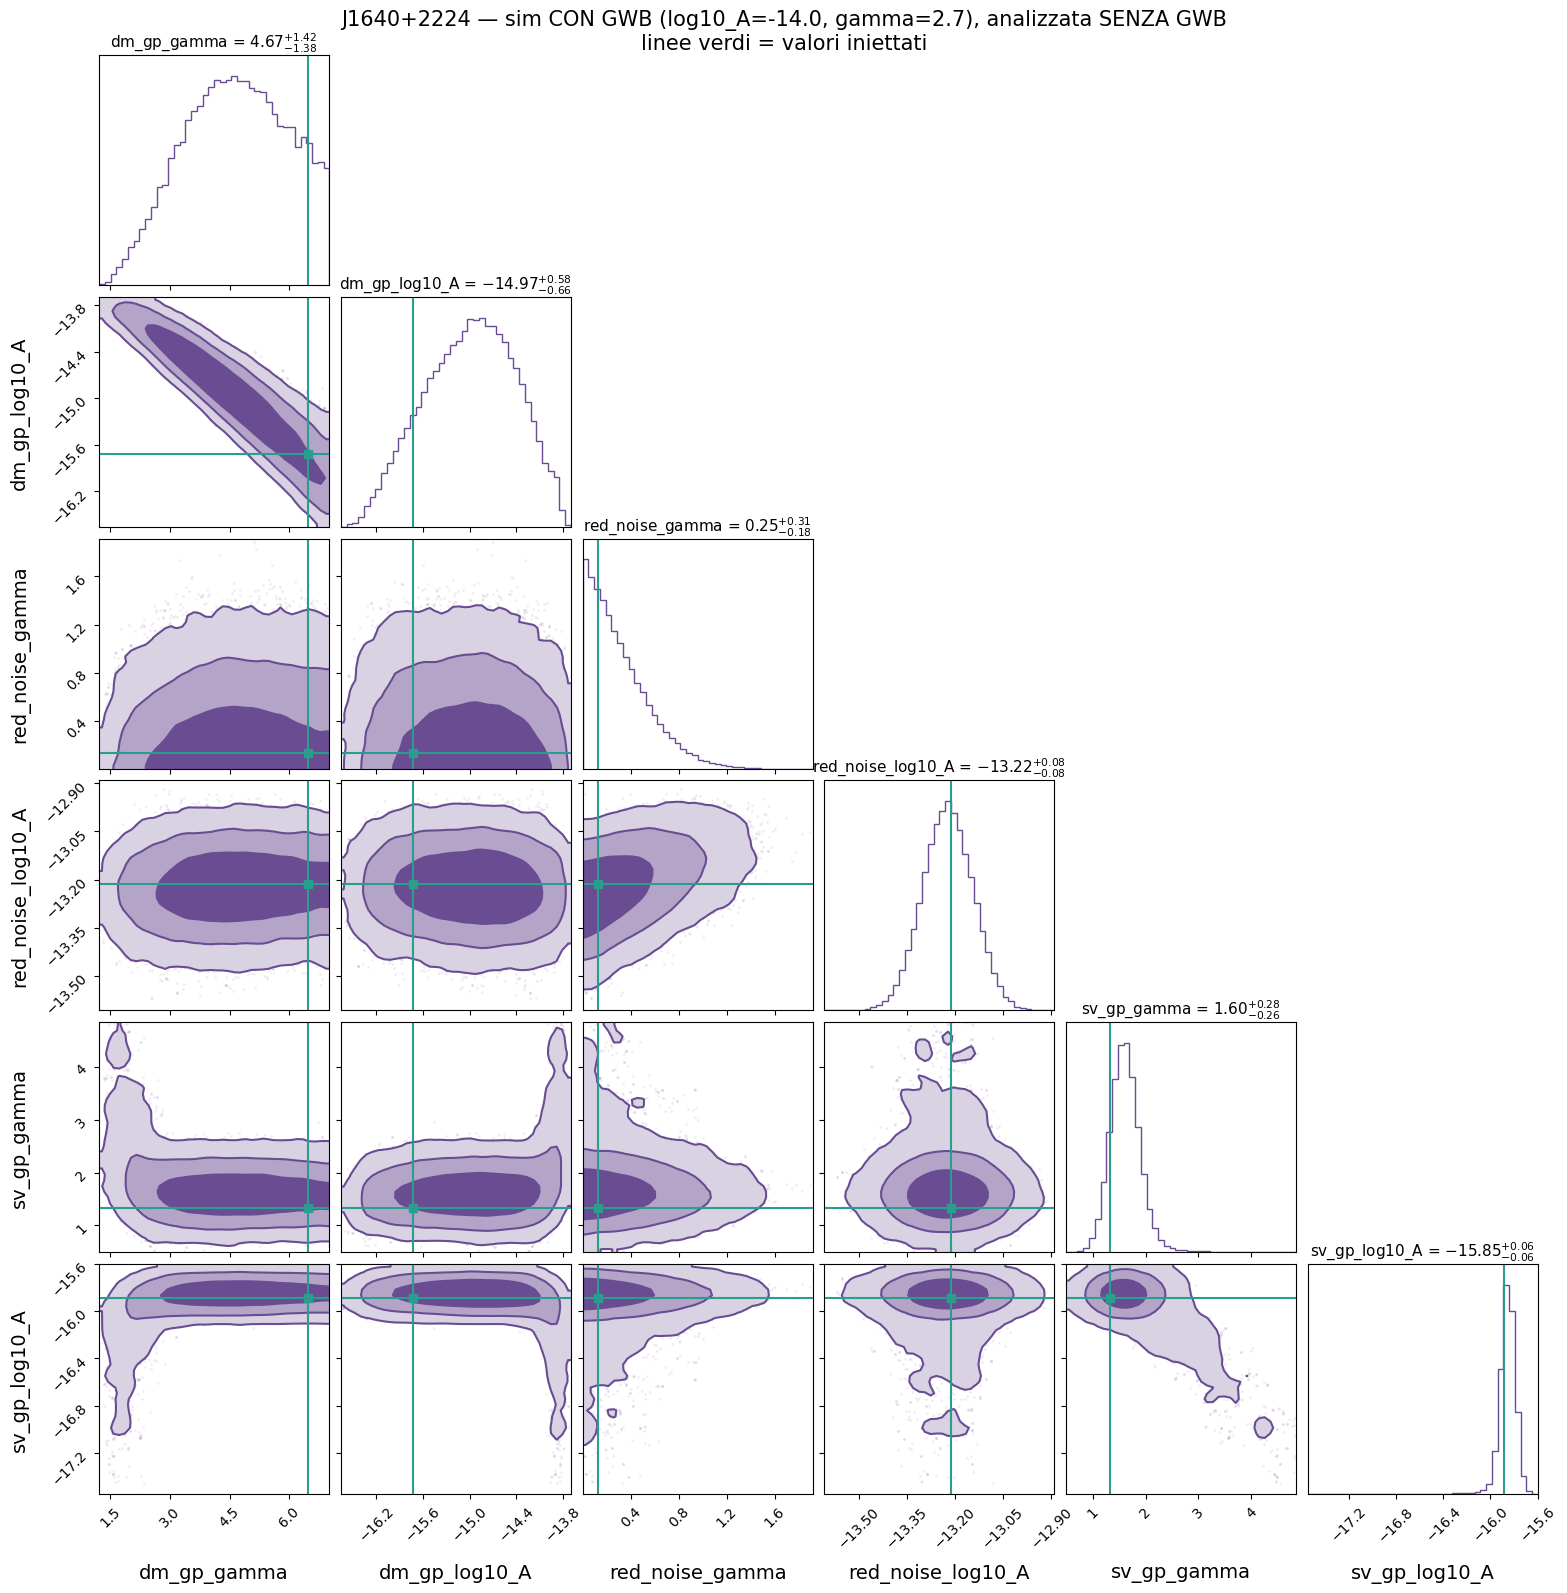

In [26]:
import corner

# valori veri iniettati (processi di rumore, senza GWB)
truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL_sim_gwb4.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim_gwb4.params]

fig = corner.corner(
    chain_sim_gwb4,
    labels=clean_labels,
    truths=truth_values,
    truth_color='#2A9D8F',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#6A4C93',
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0, smooth1d=None,
    bins=40,
    hist_kwargs={"density": True}
)
fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — sim CON GWB (log10_A=-14.0, gamma=2.7), analizzata SENZA GWB\nlinee verdi = valori iniettati', fontsize=15, y=1.00)
fig.savefig('corner_sim_gwb_A140_g27.png', dpi=150, bbox_inches='tight')

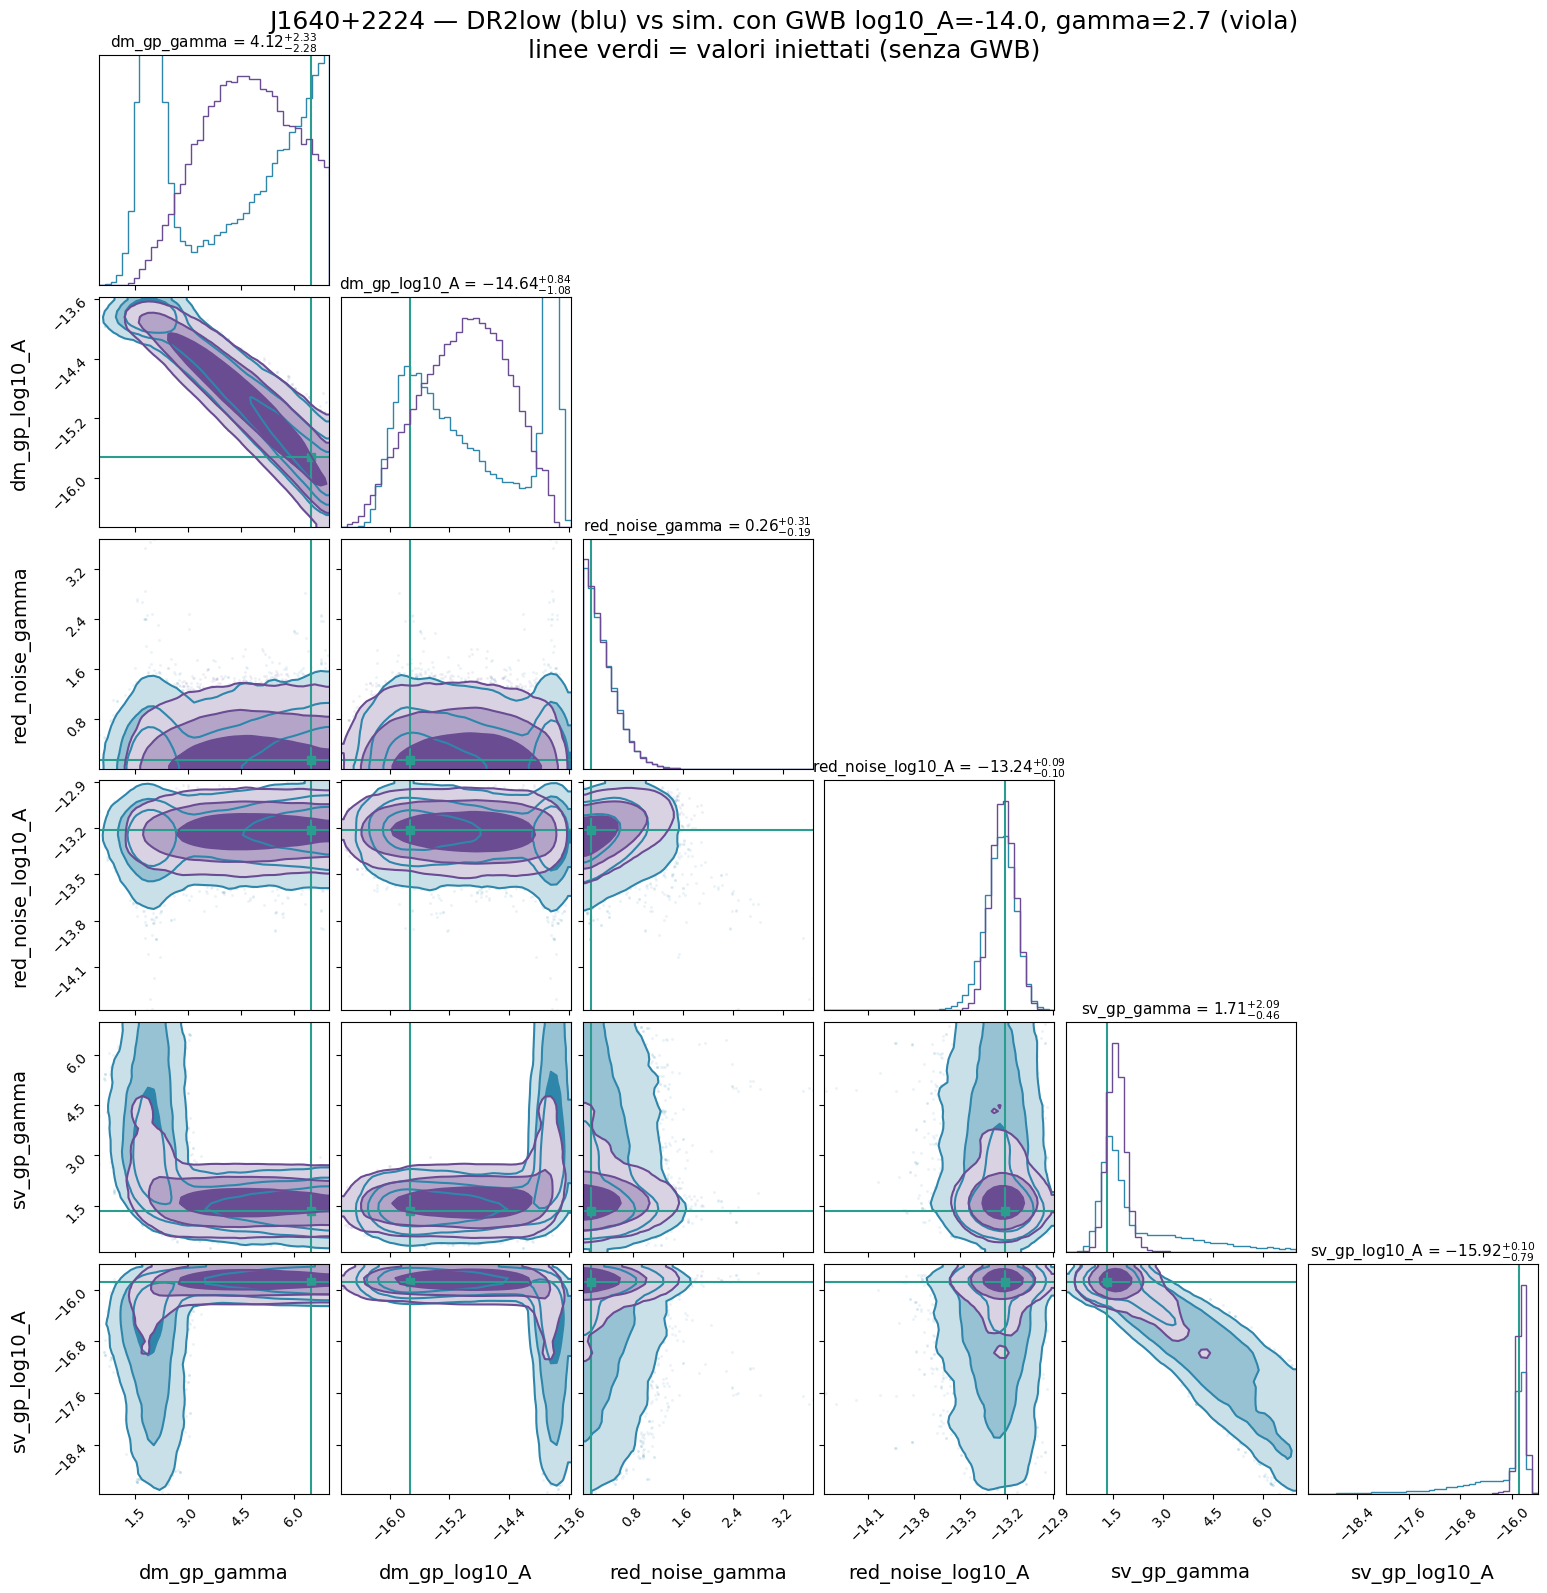

In [24]:
import corner

clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim_gwb4.params]

# valori veri iniettati (processi di rumore, senza GWB)
truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL_sim_gwb4.params]

# range comune che contiene entrambe le catene (per una sovrapposizione equa)
both = np.vstack([chain, chain_sim_gwb4])
common_range = [(both[:, i].min(), both[:, i].max()) for i in range(both.shape[1])]

fig = corner.corner(
    chain,
    labels=clean_labels,
    truths=truth_values,
    truth_color='#2A9D8F',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#2E86AB',
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    hist_kwargs={"density": True}
)

corner.corner(
    chain_sim_gwb4,
    labels=clean_labels,
    show_titles=False,
    color='#6A4C93',
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    fig=fig,
    hist_kwargs={"density": True}
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — DR2low (blu) vs sim. con GWB log10_A=-14.0, gamma=2.7 (viola)\nlinee verdi = valori iniettati (senza GWB)', fontsize=18, y=1.00)
fig.savefig('corner_reali_vs_simGWB_A140_g27.png', dpi=150, bbox_inches='tight')

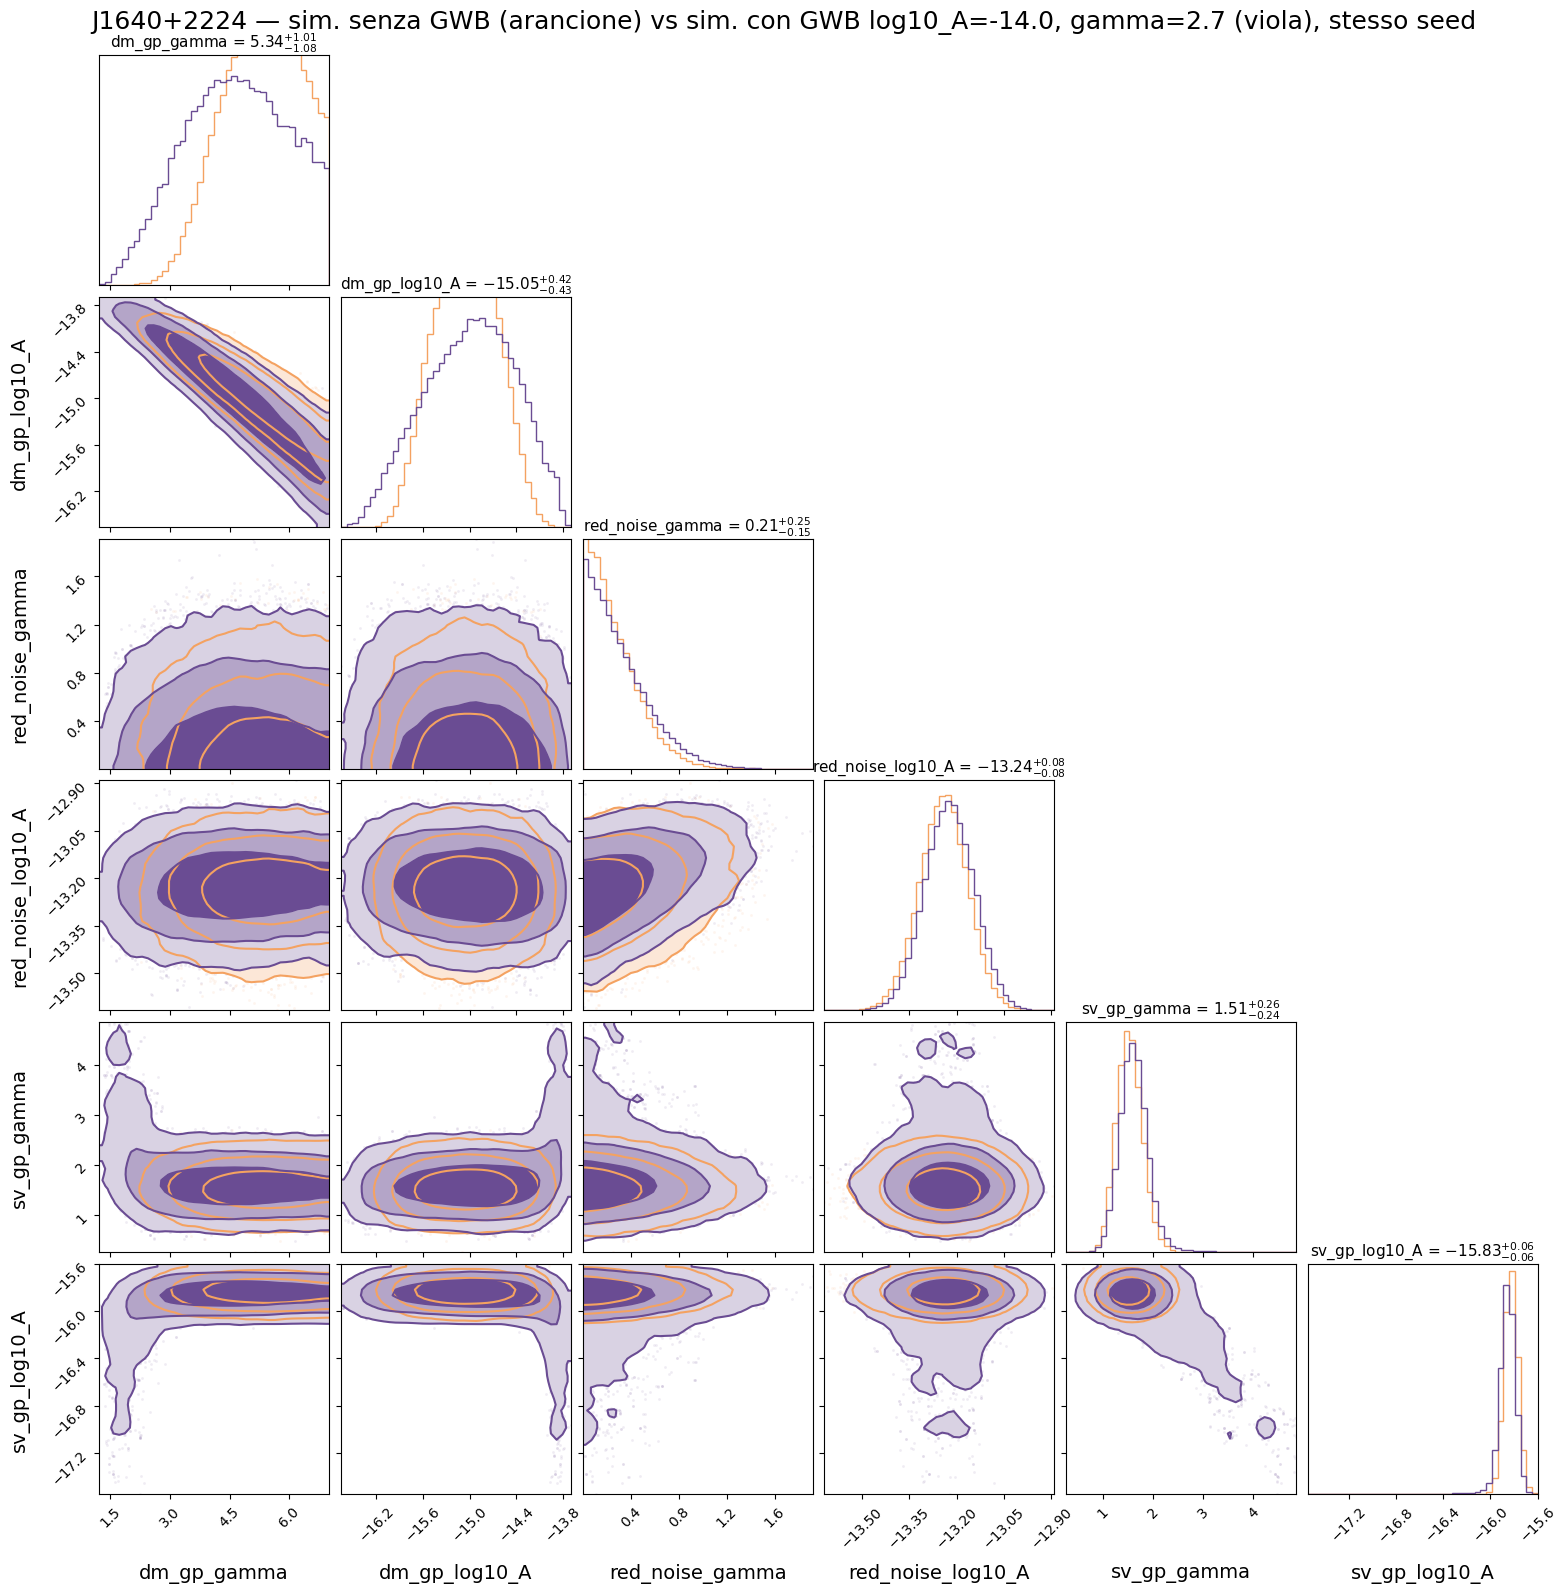

In [23]:
import corner

clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim_gwb4.params]

# range comune che contiene entrambe le catene (per una sovrapposizione equa)
both = np.vstack([chain_sim, chain_sim_gwb4])
common_range = [(both[:, i].min(), both[:, i].max()) for i in range(both.shape[1])]

fig = corner.corner(
    chain_sim,
    labels=clean_labels,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#F4A261',
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    hist_kwargs={"density": True}
)

corner.corner(
    chain_sim_gwb4,
    labels=clean_labels,
    show_titles=False,
    color='#6A4C93',
    fill_contours=True,
    levels=(0.68, 0.95, 0.997),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    fig=fig,
    hist_kwargs={"density": True}
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — sim. senza GWB (arancione) vs sim. con GWB log10_A=-14.0, gamma=2.7 (viola), stesso seed', fontsize=18, y=1.00)
fig.savefig('corner_sim_confronto_gwb_A140_g27_no_gwb.png', dpi=150, bbox_inches='tight')